In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Bakery.csv to Bakery.csv


In [7]:
import pandas as pd


df = pd.read_csv("Bakery.csv")

df.head(-1)

,TransactionNo,Items,DateTime,Daypart,DayType
0,1,Bread,2016-10-30 09:58:11,Morning,Weekend
1,2,Scandinavian,2016-10-30 10:05:34,Morning,Weekend
2,2,Scandinavian,2016-10-30 10:05:34,Morning,Weekend
3,3,Hot chocolate,2016-10-30 10:07:57,Morning,Weekend
4,3,Jam,2016-10-30 10:07:57,Morning,Weekend
...,...,...,...,...,...
20501,9682,Tacos/Fajita,2017-09-04 14:32:58,Afternoon,Weekend
20502,9682,Coffee,2017-09-04 14:32:58,Afternoon,Weekend
20503,9682,Tea,2017-09-04 14:32:58,Afternoon,Weekend
20504,9683,Coffee,2017-09-04 14:57:06,Afternoon,Weekend


In [ ]:
# Check all values
print(df.isna())

       TransactionNo  Items  DateTime  Daypart  DayType
0              False  False     False    False    False
1              False  False     False    False    False
2              False  False     False    False    False
3              False  False     False    False    False
4              False  False     False    False    False
...              ...    ...       ...      ...      ...
20502          False  False     False    False    False
20503          False  False     False    False    False
20504          False  False     False    False    False
20505          False  False     False    False    False
20506          False  False     False    False    False

[20507 rows x 5 columns]


In [ ]:
print(df.isna().sum())

TransactionNo    0
Items            0
DateTime         0
Daypart          0
DayType          0
dtype: int64


TransactionNo    0
Items            0
DateTime         0
Daypart          0
DayType          0
dtype: int64

This output meanes there are no missing value

In [ ]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

,0


In [ ]:
df.drop_duplicates(inplace=True)

On this line , I used this code to remove duplicate data, and it returned zero. **There is an image in the data description file for confirmation.**
df.drop_duplicates(inplace=True)

In [ ]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (18887, 5) 

number of rows:  18887
number of columns:  5


**the** Date time columns was of taype object **str** so That's why I used this  command to fix it.

In [13]:
df['DateTime'] = pd.to_datetime(df['DateTime'], errors='coerce')

In [12]:
# viewing the data types of columns
df.dtypes

,0
TransactionNo,int64
Items,object
DateTime,datetime64[ns]
Daypart,object
DayType,object
Hour,int32
Day,object


In [ ]:
# Statistical summary
df.describe(include='all')

,TransactionNo,Items,DateTime,Daypart,DayType
count,18887.000000,18887,18887,18887,18887
unique,NaN,94,9465,4,2
top,NaN,Coffee,2017-05-04 17:22:22,Afternoon,Weekday
freq,NaN,4528,10,10687,11830
mean,4951.051517,NaN,NaN,NaN,NaN
std,2811.619306,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN
25%,2496.500000,NaN,NaN,NaN,NaN
50%,5082.000000,NaN,NaN,NaN,NaN
75%,7378.500000,NaN,NaN,NaN,NaN


I converted the date column into a correct time format, then extracted the time clock as an independent variable (Feature) to study recurring patterns throughout the day.

In [14]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Hour'] = df['DateTime'].dt.hour

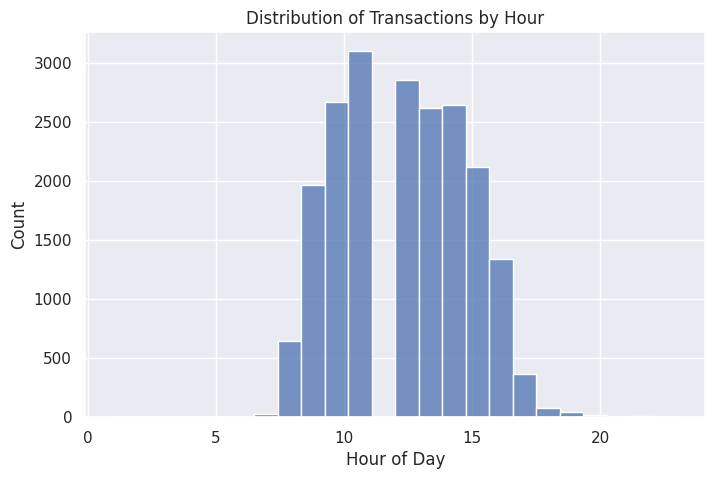

In [16]:

plt.figure(figsize=(8,5))
sns.histplot(df['Hour'], bins=24)
plt.title("Distribution of Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.show()

This histogram shows the distribution of transactions throughout the day, with activity peaking significantly around 11:00 AM. Most transactions occur between 8:00 AM and 5:00 PM, while the hours before 7:00 AM and after 8:00 PM see very little to no activity.

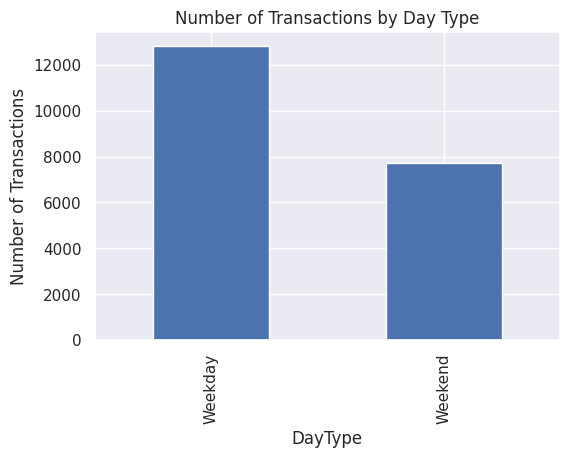

,count
DayType,
Weekday,12807
Weekend,7700


In [27]:
daytype_count = df['DayType'].value_counts()

plt.figure(figsize=(6,4))
daytype_count.plot(kind='bar')
plt.title("Number of Transactions by Day Type")
plt.ylabel("Number of Transactions")
plt.show()

daytype_count

This bar chart compares the total volume of transactions between weekdays and weekends. It shows that weekdays account for over 12,000 transactions, significantly outperforming weekends, which record fewer than 8,000.

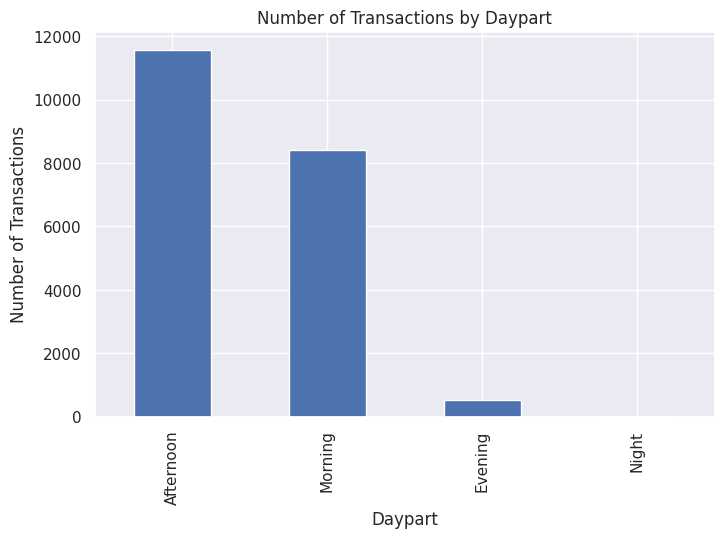

,count
Daypart,
Afternoon,11569
Morning,8404
Evening,520
Night,14


In [31]:
daypart_count = df['Daypart'].value_counts()

plt.figure(figsize=(8,5))
daypart_count.plot(kind='bar')
plt.title("Number of Transactions by Daypart")
plt.ylabel("Number of Transactions")
plt.show()

daypart_count

This bar chart highlights that most transactions occur during the afternoon and morning, totaling nearly 20,000 combined. In contrast, activity drops sharply in the evening and becomes almost non-existent at night.

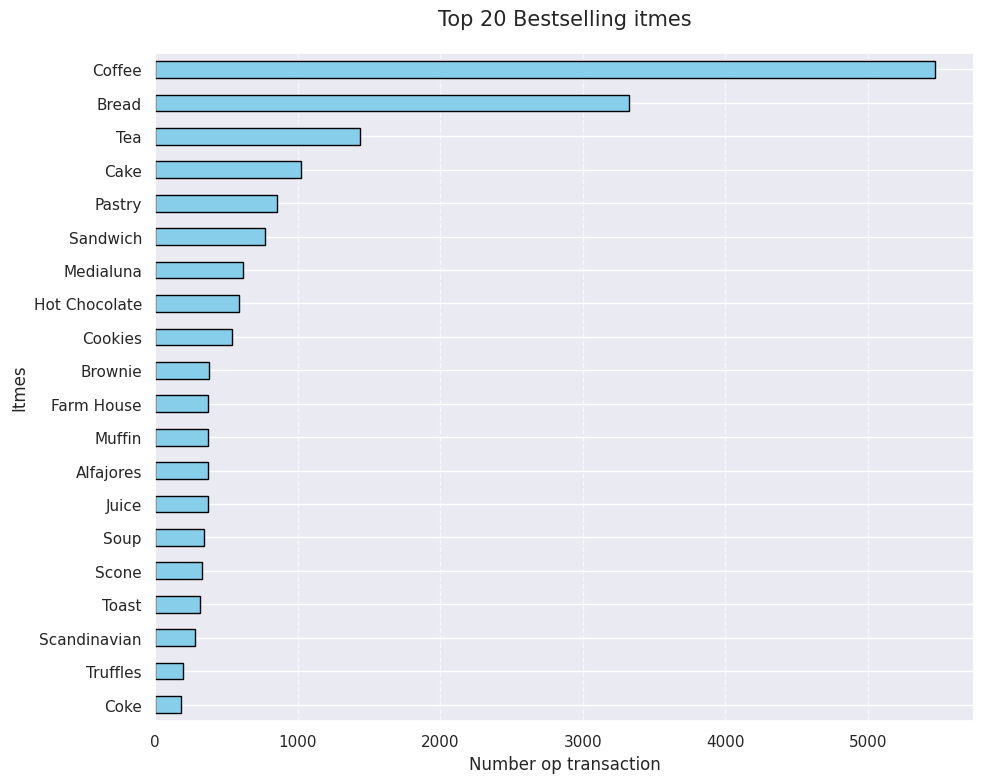

In [39]:
import matplotlib.pyplot as plt

top_items = df['Items'].value_counts().head(20)

plt.figure(figsize=(10, 8))

top_items.sort_values().plot(kind='barh', color='skyblue', edgecolor='black')

plt.title("Top 20 Bestselling itmes", fontsize=15, pad=20)
plt.xlabel("Number op transaction", fontsize=12)
plt.ylabel("Itmes", fontsize=12)

# 5. إضافة شبكة خلفية للمساعدة في القراءة
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

This horizontal bar chart displays the top 20 bestselling items, with "Coffee" and "Bread" being the most popular by a significant margin. While the top few items reach thousands of transactions, the majority of products on the list maintain a lower, more consistent volume below 1,000.

In [40]:

top_products = df['Items'].value_counts().head(10)
top_products

,count
Items,
Coffee,5471
Bread,3325
Tea,1435
Cake,1025
Pastry,856
Sandwich,771
Medialuna,616
Hot Chocolate,590
Cookies,540


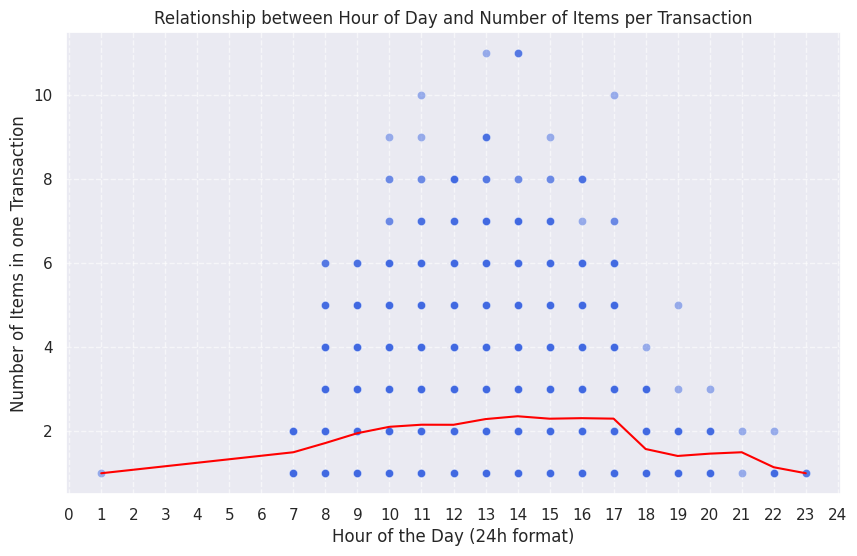

In [53]:

df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Hour'] = df['DateTime'].dt.hour

transaction_summary = df.groupby('TransactionNo').agg({
    'Items': 'count',
    'Hour': 'first'
}).rename(columns={'Items': 'Num_Items'})


plt.figure(figsize=(10, 6))

sns.scatterplot(x='Hour', y='Num_Items', data=transaction_summary, alpha=0.5, color='royalblue')


sns.lineplot(x='Hour', y='Num_Items', data=transaction_summary, color='red', errorbar=None)

plt.title("Relationship between Hour of Day and Number of Items per Transaction")
plt.xlabel("Hour of the Day (24h format)")
plt.ylabel("Number of Items in one Transaction")
plt.xticks(range(0, 25))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

This scatter plot illustrates the relationship between the time of day and transaction size, showing that most shopping activity occurs between 8:00 and 22:00. While individual orders vary significantly, the red trend line indicates that the average number of items per transaction remains steady at around two.

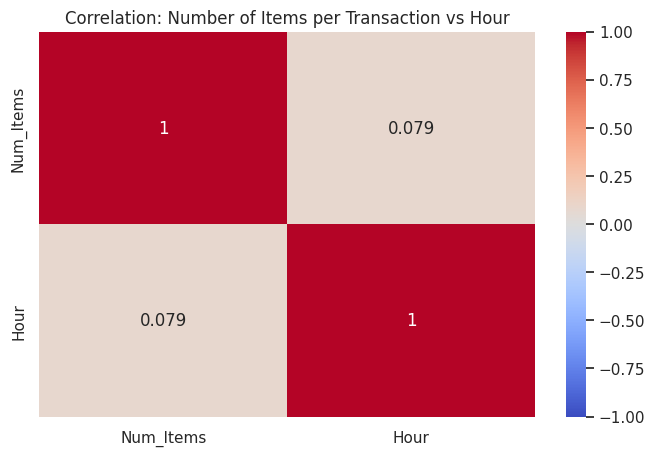

In [56]:

df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Hour'] = df['DateTime'].dt.hour


transaction_data = df.groupby('TransactionNo').agg({
    'Items': 'count',
    'Hour': 'first'
}).rename(columns={'Items': 'Num_Items'})


plt.figure(figsize=(8, 5))
sns.heatmap(transaction_data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation: Number of Items per Transaction vs Hour")
plt.show()

The heatmap displays the Pearson correlation between the hour of the day and the number of items per transaction. The correlation coefficient is 0.079, which is very close to zero. This indicates that there is no meaningful linear relationship between the time of day and the size of a customer's order; customers tend to buy a similar number of items regardless of whether it is morning or afternoon.

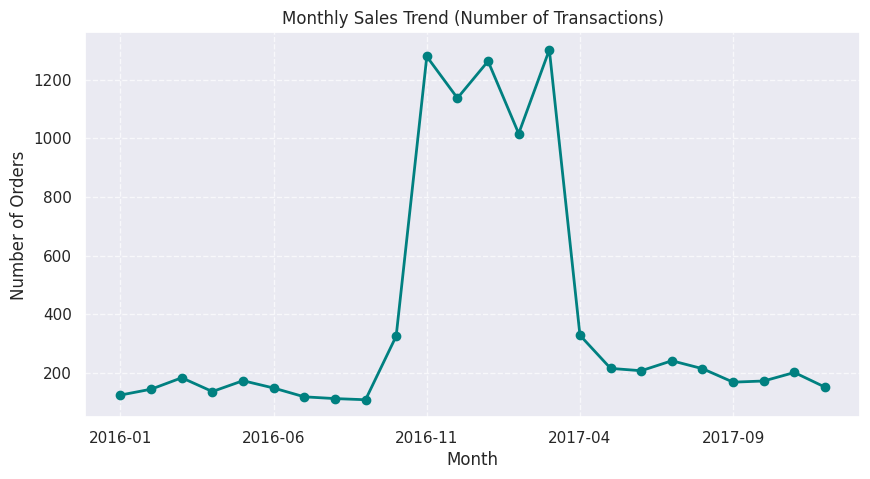

In [57]:

df['Month'] = df['DateTime'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TransactionNo'].nunique()


plt.figure(figsize=(10,5))

monthly_sales.index = monthly_sales.index.astype(str)
monthly_sales.plot(kind='line', marker='o', color='teal', linewidth=2)

plt.title("Monthly Sales Trend (Number of Transactions)")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This line chart illustrates the monthly transaction volume from January 2016 to early 2018. A significant surge in sales is observed between November 2016 and March 2017, reaching a peak of over 1,200 transactions per month. Following this peak, the sales volume stabilized at a higher baseline compared to the early months of 2016, indicating a growth in the bakery's customer base over time.